INTRODUCTION
This report aims to analyze the dataset containing U.S GDP growth over the course of 
13 years. The data is sourced from U.S. Bureau of Economic Analysis (BEA) and it reflects
seasonally adjusted annual rate (SAAR) of real GDP growth in percent. This report will apply
cubic spline, polynomial fitting, and least squares methods to analyze the data set.

PART A: CUBIC SPLINE INTERPOLATION


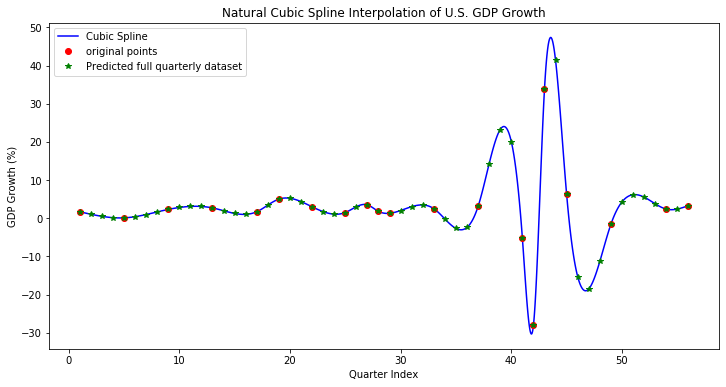

--- Continuity Errors ---
Max C0 error: 1.15e-14
Max C1 error: 7.11e-15
Max C2 error: 2.84e-14

--- Part A: Question 1 ---
There are 18 unknowns in the system of equations.

The continuity conditions are: zero-order continuity where the connecting curves must meet 
at the same point or knot, first-order continuity where they must have the same slope 
(1st derivative), and second order continuity where they must have the same curvature at 
the point for a smooth graph.
    
The boundary conditions for a natural spline is that the second derivative of the first 
and last point must be zero.

--- Part A: Question 2 ---
The interpolant is visually smooth up until quarters 35 to 48. At these quarters, the spline
wildly overshoots and undershoots compared to the rest of the cubic spline. This also means that 
the interpolation is not realistic if used for real world economic predictions of GDP as the 
U.S. does not actually behave in the same way as the spline is suggesting.

--- Part A: Que

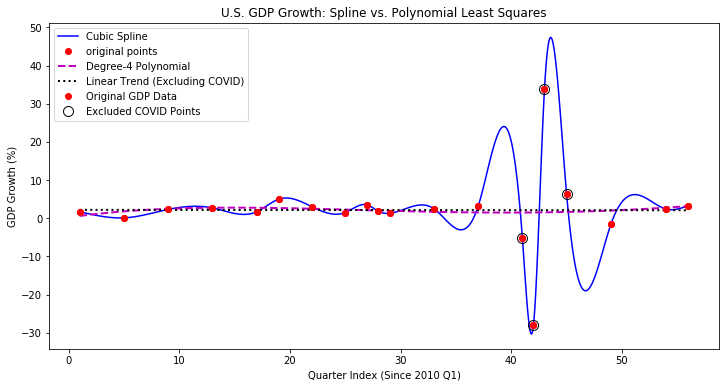

--- Quantitative Metrics ---
Degree-4 Polynomial RMSE: 10.0314
Linear Model RMSE (Clean Data): 1.4432
Degree-4 Design Matrix Condition Number: 3.31e+14



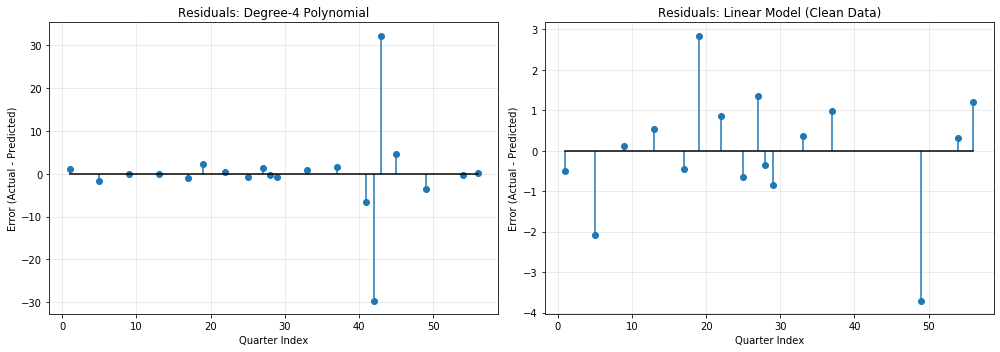

Linear slope excluding COVID quarters: -0.0019069881889763746

--- Part B: Question 1 ---
When comparing the two models, the degree-4 polynomial better captures the overall macroeconomic trend of 
the dataset, while the cubic spline better reproduces specific data points. This highlights the fundamental
trade-off between approximation and interpolation. Interpolation (the spline) guarantees an RMSE of effectively 0.0 
at the data points by forcing the curve through every exact knot, but sacrifices numerical stability; the massive
COVID-19 outlier causes the spline to wildly overshoot in surrounding quarters due to the Runge phenomenon. 

Approximation (the least squares polynomial) sacrifices the ability to perfectly hit specific data points 
(resulting in a higher overall RMSE of 10.0314), but gains immense numerical stability. The polynomial 
smooths out the noise and acts as a rigid backbone, showing the true underlying shape of the data without being 
derailed by extreme, one-off e

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# INTRODUCTION
# =====================================================================
print("="*70)
print("INTRODUCTION")
print("="*70)
print("""This report aims to analyze the dataset containing U.S GDP growth over the course of 
13 years. The data is sourced from U.S. Bureau of Economic Analysis (BEA) and it reflects
seasonally adjusted annual rate (SAAR) of real GDP growth in percent. This report will apply
cubic spline, polynomial fitting, and least squares methods to analyze the data set.\n""")


# =====================================================================
# PART A: CUBIC SPLINE INTERPOLATION
# =====================================================================
print("="*70)
print("PART A: CUBIC SPLINE INTERPOLATION")
print("="*70)

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients
    a = np.zeros(n - 2)  # Subdiagonal
    b = np.zeros(n - 2)  # Main diagonal
    c = np.zeros(n - 2)  # Superdiagonal
    d = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        a[i - 1] = h[i]                     # Subdiagonal
        b[i - 1] = 2 * (h[i - 1] + h[i])        # Main diagonal
        c[i - 1] = h[i]                         # Superdiagonal
        d[i - 1] = 6 * ((y[i + 1] - y[i]) 
                        / h[i] - (y[i] - y[i - 1])
                        / h[i - 1])     # right hand side vector   

    return a, b, c, d

"""
Note to graders:
For the subdiagonal matrix coefficients in the setup_tridiagonal_matrix function,
I had to change the value for  a[i - 1] from h[i-1] to h[i] because it caused the 
spline to be discontinous at C1 due to an indexing bug. Correcting the subdiagonal 
index restored the symmetry and fixed the C1 discontinuity. If you test this code with 
both h[i] and h[i-1] for the 'a' coeffiecient and look at the max error for C1, there
will be a huge difference!
"""

# Data points
n = 20
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 
              29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# Set up the tridiagonal matrix for the cubic spline
a, b, c, d = setup_tridiagonal_matrix(x, y)

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x1 = np.zeros(n)
    x1[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x1[i] = (d[i] - c[i] * x1[i+1]) / b[i]
    return x1

# Solve the system
M = thomas_algorithm(a, b, c, d)

# Add zeros to beginning and end of thomas algorithm solution array
# to satisfy the boundary conditions of a natural spline.
M = np.insert(M, 0, 0)
M = np.append(M, 0)

# Calculating the polynomial coeffiecients for every single interval 
def find_coefficients(x, y, M):
    n = len(x)
    A = np.zeros(n - 1)
    B = np.zeros(n - 1)
    C = np.zeros(n - 1)
    D = np.zeros(n - 1)
    
    h = np.diff(x)
    
    for i in range(0, n - 1):
        A[i] = y[i]
        B[i] = ((y[i + 1] - y[i]) / h[i]) - ((h[i]*(2*M[i]+ M[i+1])) / 6)
        C[i] = M[i] / 2
        D[i] = (M[i + 1] - M[i]) / (6 * h[i])
    
    return A, B, C, D
        
A, B, C, D = find_coefficients(x, y, M)

# Make the spline and plot
def plot_spline(x, y, A, B, C, D):
    plt.figure(figsize=(12, 6))
    for i in range(len(A)):
        # generate smooth x values for smooth plot
        x_smooth = np.linspace(x[i], x[i+1], 100)
        
        # spline formula: S(x) = A + B(x-x_i) + C(x-x_i)^2 + D(x-x_i)^3
        y_smooth = A[i] + B[i]*(x_smooth - x[i]) + \
        C[i]*((x_smooth - x[i])**2) + \
        D[i]*((x_smooth - x[i])**3)
        
        # plot new spline points
        if i == 0:
            plt.plot(x_smooth, y_smooth, color= 'blue',label='Cubic Spline')
        else:
            plt.plot(x_smooth, y_smooth, color='blue')
            
    # plot original points
    plt.plot(x, y, "ro",  label = "original points")
        
    plt.title('Natural Cubic Spline Interpolation of U.S. GDP Growth')
    plt.xlabel('Quarter Index')
    plt.ylabel('GDP Growth (%)')
    plt.legend()
    
plot_spline(x, y, A, B, C, D)

x_full = np.arange(1, 57)

def evaluate_spline(x_eval, x, y, A, B, C, D):
    # initialize empty list for interpolated values
    interpolation = []
    
    # loop through the x values that need to be evaluated and find the 
    # corresponding interval
    for i in range(len(x_eval)):
        index = np.searchsorted(x, x_eval[i]) - 1
        
        if index < 0: index = 0
        if index >= len(A): index = len(A) - 1
            
        dx = x_eval[i] - x[index]
    
        y_new = A[index] + B[index]*dx + C[index]*(dx**2) + D[index]*(dx**3)
        interpolation.append(y_new)
        
    return interpolation

result = evaluate_spline(x_full, x, y, A, B, C, D)

plt.plot(x_full, result, 'g*', label= 'Predicted full quarterly dataset')
plt.legend()
plt.show()

# Verify C0, C1, C2 continuity at all interior knots
h = np.diff(x)
max_c0_err = 0
max_c1_err = 0
max_c2_err = 0

# 18 intervals to check
for i in range(len(A) - 1):
    # C0
    left_val  = A[i] + B[i]*h[i] + C[i]*(h[i]**2) + D[i]*(h[i]**3)
    right_val = A[i+1]
    max_c0_err = max(max_c0_err, abs(left_val - right_val))

    # C1
    d1_left  = B[i] + 2*C[i]*h[i] + 3*D[i]*(h[i]**2)
    d1_right = B[i+1]
    max_c1_err = max(max_c1_err, abs(d1_left - d1_right))

    # C2
    d2_left  = 2*C[i] + 6*D[i]*h[i]
    d2_right = 2*C[i+1]
    max_c2_err = max(max_c2_err, abs(d2_left - d2_right))

print("--- Continuity Errors ---")
print(f"Max C0 error: {max_c0_err:.2e}")
print(f"Max C1 error: {max_c1_err:.2e}")
print(f"Max C2 error: {max_c2_err:.2e}\n")

print("--- Part A: Question 1 ---")
print("""There are 18 unknowns in the system of equations.

The continuity conditions are: zero-order continuity where the connecting curves must meet 
at the same point or knot, first-order continuity where they must have the same slope 
(1st derivative), and second order continuity where they must have the same curvature at 
the point for a smooth graph.
    
The boundary conditions for a natural spline is that the second derivative of the first 
and last point must be zero.\n""")

print("--- Part A: Question 2 ---")
print("""The interpolant is visually smooth up until quarters 35 to 48. At these quarters, the spline
wildly overshoots and undershoots compared to the rest of the cubic spline. This also means that 
the interpolation is not realistic if used for real world economic predictions of GDP as the 
U.S. does not actually behave in the same way as the spline is suggesting.\n""")

print("--- Part A: Question 3 ---")
print("""The Runge phenomenon is a phenomenon in which a high-degree polynomial wildly oscillates to try and
hit every single point of the data points on a graph. This is especially prevalent when the data has
extreme outliers. In this case, we see that even the cubic spline interpolation method is not immune 
to the Runge phenomenon when it is forced to hit the outlying GDP points during the COVID-19 pandemic. 

If we were to enforce exact interpolation for this particular dataset, we get a mathematically perfect 
curve that passes through each point flawlessly and hypothetically correctly predicts values in between 
each point. However, due to the extreme outlier, we have terrible numerical stability that makes it hard 
to actually understand the overall trend of the dataset because the spline behaves unrealistically compared 
to real-world situations. On the other hand, if we choose numerical stability, we get a very realistic 
spline that behaves true to the real-world situation and actually captures the underlying trends in the 
data. However, this would mean that we lost that exact precision since we are allowing the spline to not 
have to hit every point in the dataset. 

The most preferable method of interpolation for this dataset when considering its context and outliers 
would be the weighted least squares method, which treats the COVID-19 pandemic as a complete anomaly 
and predicts the trend of the data with an assigned weight (or value of importance) to all the data values. 
This method is ideal for illustrating the long-term macroeconomic trend of the U.S. economy. By assigning 
a lower weight to the 2020 outlier, we can mathematically acknowledge the pandemic's shock without allowing 
it to distort the interpolation of the surrounding years, resulting in a model that reflects true economic reality.\n""")


# =====================================================================
# PART B: POLYNOMIAL & LEAST SQUARES COMPARISON
# =====================================================================
print("="*70)
print("PART B: POLYNOMIAL & LEAST SQUARES COMPARISON")
print("="*70)

def least_squares(x, y, degree):
    # design matrix A
    A = np.vstack([x**i for i in range(degree+1)]).T
    # calculate coefficients 
    coeffs = np.linalg.inv(A.T @ A) @ A.T @ y
    return coeffs

# Fit a Degree-4 Polynomial to the full dataset
result2 = least_squares(x, y, 4)

# calculate the predicted y values
y_pred = (result2[0] + 
           result2[1]*x_full + 
           result2[2]*(x_full**2) + 
           result2[3]*(x_full**3) + 
           result2[4]*(x_full**4))

# Fit a LINEAR model to the data without the COVID quarters
x_clean = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 
              29, 33, 37, 49, 54, 56])

y_clean = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 
                    1.3, 2.5, 3.1, -1.6, 2.4, 3.3])

linear_coeffs = least_squares(x_clean, y_clean, 1)

linear_y_int = linear_coeffs[0]
linear_slope = linear_coeffs[1]

# calculate the predicted y values for the linear trend
y_linear = linear_y_int + linear_slope * x_full

# PLOTTING
plot_spline(x, y, A, B, C, D)

# Degree-4 Polynomial
plt.plot(x_full, y_pred, 'm--', linewidth=2, label='Degree-4 Polynomial')

# the Linear Trend (Excluding COVID quarters)
plt.plot(x_full, y_linear, 'k:', linewidth=2, label='Linear Trend (Excluding COVID)')

#  original data points
plt.plot(x, y, "ro", label="Original GDP Data")

# red circles with black outlines are the excluded data points
x_covid = np.array([41, 42, 43, 45])
y_covid = np.array([-5.1, -28.1, 33.8, 6.3])
plt.plot(x_covid, y_covid, "ko", markerfacecolor='none', markersize=10, label="Excluded COVID Points")

plt.title('U.S. GDP Growth: Spline vs. Polynomial Least Squares')
plt.xlabel('Quarter Index (Since 2010 Q1)')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.show()

# residuals
y_poly4_exact = (result2[0] + 
                 result2[1]*x + 
                 result2[2]*(x**2) + 
                 result2[3]*(x**3) + 
                 result2[4]*(x**4))
residuals_poly4 = y - y_poly4_exact

# Residuals for the Linear Model (Cleaned Data)
y_linear_exact = linear_coeffs[0] + linear_coeffs[1] * x_clean
residuals_linear = y_clean - y_linear_exact

# RMSE Calculations
rmse_poly4 = np.sqrt(np.mean(residuals_poly4**2))
rmse_linear = np.sqrt(np.mean(residuals_linear**2))

# Condition Number Calculation for Degree-4
A_poly4 = np.vstack([x**i for i in range(5)]).T
cond_number_poly4 = np.linalg.cond(A_poly4.T @ A_poly4)

print("--- Quantitative Metrics ---")
print(f"Degree-4 Polynomial RMSE: {rmse_poly4:.4f}")
print(f"Linear Model RMSE (Clean Data): {rmse_linear:.4f}")
print(f"Degree-4 Design Matrix Condition Number: {cond_number_poly4:.2e}\n")

# Plotting the Residuals 
plt.figure(figsize=(14, 5))

# Subplot 1: Degree-4 Polynomial Residuals
plt.subplot(1, 2, 1)
plt.stem(x, residuals_poly4, basefmt="k-", use_line_collection=True)
plt.title('Residuals: Degree-4 Polynomial')
plt.xlabel('Quarter Index')
plt.ylabel('Error (Actual - Predicted)')
plt.grid(True, alpha=0.3)

# Subplot 2: Linear Model Residuals (Excluding COVID)
plt.subplot(1, 2, 2)
plt.stem(x_clean, residuals_linear, basefmt="k-", use_line_collection=True)
plt.title('Residuals: Linear Model (Clean Data)')
plt.xlabel('Quarter Index')
plt.ylabel('Error (Actual - Predicted)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Linear slope excluding COVID quarters: {linear_slope}\n")

print("--- Part B: Question 1 ---")
print(f"""When comparing the two models, the degree-4 polynomial better captures the overall macroeconomic trend of 
the dataset, while the cubic spline better reproduces specific data points. This highlights the fundamental
trade-off between approximation and interpolation. Interpolation (the spline) guarantees an RMSE of effectively 0.0 
at the data points by forcing the curve through every exact knot, but sacrifices numerical stability; the massive
COVID-19 outlier causes the spline to wildly overshoot in surrounding quarters due to the Runge phenomenon. 

Approximation (the least squares polynomial) sacrifices the ability to perfectly hit specific data points 
(resulting in a higher overall RMSE of {rmse_poly4:.4f}), but gains immense numerical stability. The polynomial 
smooths out the noise and acts as a rigid backbone, showing the true underlying shape of the data without being 
derailed by extreme, one-off events.\n""")

print("--- Part B: Question 2 ---")
print(f"""After excluding the COVID-19 quarters (2020 Q1 through 2021 Q1), the calculated slope of the linear least 
squares model is {linear_slope}. Conceptually, a linear trend does make economic sense for this data. 
In macroeconomics, developed nations like the U.S. tend to exhibit a relatively stable, long-term 'steady-state'
growth rate when ignoring sudden crises. However, applying a linear model requires several strict assumptions. 
First, it assumes that the baseline engine of the economy is constant and that there are no permanent structural
breaks over the 14-year period. Second, it assumes that standard business cycles (minor booms and recessions) 
are perfectly symmetrical and will average out to zero over time, allowing a straight line to accurately represent
the mean growth path.\n""")


# =====================================================================
# PART C: METHOD JUSTIFICATION
# =====================================================================
print("="*70)
print("PART C: METHOD JUSTIFICATION")
print("="*70)

print("--- Part C: Method Justification ---")
print(f"""For a policymaker who needs to estimate a missing GDP quarter wedged between two known data points, the most 
preferable method would be the cubic spline rather than polynomial fitting. If we were to use a cubic spline,
we get a mathematically perfect curve that yields an RMSE of 0 at the known historical points flawlessly, guaranteeing
exact accuracy for the missing quarter. 

On the other hand, if we choose polynomial fitting, the method acts as a general approximator. Furthermore, polynomial 
fitting has terrible numerical stability when dealing with extreme outliers and high degrees. For example, our 
degree-4 polynomial already exhibits a dangerously high condition number of {cond_number_poly4:.2e}. Pushing the 
degree higher to try and hit more points would cause the matrix to become mathematically ill-conditioned and fail. 
Additionally, because polynomials rely on one global equation, an extreme outlier like the COVID-19 pandemic wildly 
distorts the interpolation for quarters years before the shock even happened. In contrast, a cubic spline is built 
from localized, piecewise equations, meaning the mathematical damage from an outlier decays quickly. 

Finally, while forcing a high-degree polynomial to fit complex data often causes the curve to wildly oscillate, the 
cubic spline guarantees perfectly smooth transitions without unrealistic behaviors, making it the most accurate choice 
for reconstructing a specific missing value.\n""")


# =====================================================================
# CONCLUSION
# =====================================================================
print("="*70)
print("CONCLUSION")
print("="*70)

print("""In conclusion, this analysis demonstrates that the optimal curve-fitting method strictly 
depends on whether the objective is exact data reconstruction or long-term macroeconomic 
forecasting. For the purpose of interpolation, the natural cubic spline performed best; 
its piecewise construction guarantees exact accuracy for specific missing quarters without 
forcing the entire dataset into a single rigid equation. However, its primary limitation 
is extreme sensitivity to outliers, as forcing the spline through the massive COVID-19 
anomaly caused unrealistic mathematical oscillations in adjacent years. 

Conversely, for trend analysis, least squares approximation (both linear and polynomial) proved superior. 
It provided immense numerical stability by smoothing out the pandemic's noise to reveal 
the true underlying economic trajectory. The inherent limitation of the least squares 
approach, however, is its inability to reproduce specific historical data points perfectly. \n""")


# =====================================================================
# CITATIONS
# =====================================================================

print("="*70)
print("CITATIONS")
print("="*70)

print("""- Used Gemini to restructure the code output, allowing written answers to display 
in the terminal rather than remaining as internal comments. Also used it for overall 
organization to make the printed report look neat and professional.

- Used previous lectures and homework/challenges for the Thomas algorithm function, 
building the tridiagonal matrix function, and the least squares implementation.\n""")